# Tox21 Feature Engineering Pipeline

This notebook builds a production-consistent molecular feature pipeline for toxicity modeling.

Core principles:
- Single feature definition used for both training and inference
- Keep NaN assay labels as not-tested indicators
- Scale descriptor columns only, never binary Morgan bits

## Cell 1 - Imports and Environment Setup

In [9]:
import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit import DataStructs
from rdkit import RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors

from sklearn.preprocessing import StandardScaler

try:
    from tqdm.auto import tqdm
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tqdm', '-q'])
    from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

## Cell 2 - Core Feature Extraction Function

The function below is the single source of truth for molecular features and should match production behavior exactly.

In [10]:
ASSAY_COLUMNS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

DESCRIPTOR_NAMES = [
    'MolWt', 'MolLogP', 'TPSA', 'NumHBD', 'NumHBA', 'NumRotatableBonds',
    'NumAromaticRings', 'NumAliphaticRings', 'HeavyAtomCount', 'FractionCSP3',
    'NumAromaticHeterocycles', 'NumSaturatedRings', 'fr_aldehyde', 'fr_epoxide',
    'fr_halogen', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'RingCount', 'NumRadicalElectrons'
]

def smiles_to_features(smiles: str) -> np.ndarray | None:
    """Convert a SMILES string to a 2068-dim feature vector or return None."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # Add explicit hydrogens before generating Morgan bits for consistency.
        mol_h = Chem.AddHs(mol)

        fp = AllChem.GetMorganFingerprintAsBitVect(mol_h, radius=2, nBits=2048)
        fp_array = np.zeros((2048,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, fp_array)

        descriptor_array = np.array([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            rdMolDescriptors.CalcNumHBD(mol),
            rdMolDescriptors.CalcNumHBA(mol),
            rdMolDescriptors.CalcNumRotatableBonds(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol),
            rdMolDescriptors.CalcNumAliphaticRings(mol),
            Descriptors.HeavyAtomCount(mol),
            Descriptors.FractionCSP3(mol),
            rdMolDescriptors.CalcNumAromaticHeterocycles(mol),
            rdMolDescriptors.CalcNumSaturatedRings(mol),
            Descriptors.fr_aldehyde(mol),
            Descriptors.fr_epoxide(mol),
            Descriptors.fr_halogen(mol),
            Descriptors.fr_NH0(mol),
            Descriptors.fr_NH1(mol),
            Descriptors.fr_NH2(mol),
            Descriptors.RingCount(mol),
            Descriptors.NumRadicalElectrons(mol),
        ], dtype=np.float32)

        return np.concatenate([fp_array, descriptor_array]).astype(np.float32)
    except Exception:
        return None


def get_descriptor_names() -> list[str]:
    """Return Morgan bit names + descriptor names in exact feature order."""
    morgan_names = [f'morgan_bit_{i}' for i in range(2048)]
    return morgan_names + DESCRIPTOR_NAMES

## Cell 3 - Load Tox21 Data

Handles both single-file and split train/test CSV layouts.

In [11]:
def resolve_ml_paths() -> tuple[Path, Path, Path]:
    """Resolve data/processed/model paths for both notebook and checkpoint locations."""
    candidates = [
        Path('../data'),      # when notebook is in backend/ml/notebooks
        Path('../../data'),   # when notebook is in backend/ml/notebooks/.ipynb_checkpoints
        Path('backend/ml/data')
    ]

    data_dir = next((p for p in candidates if p.exists()), None)
    if data_dir is None:
        checked = '\n'.join(str(p.resolve()) for p in candidates)
        raise FileNotFoundError(f'Could not resolve data directory. Checked:\n{checked}')

    ml_root = data_dir.parent
    processed_dir = ml_root / 'processed'
    trained_models_dir = ml_root / 'trained_models'

    processed_dir.mkdir(parents=True, exist_ok=True)
    trained_models_dir.mkdir(parents=True, exist_ok=True)
    return data_dir, processed_dir, trained_models_dir


DATA_DIR, PROCESSED_DIR, TRAINED_MODELS_DIR = resolve_ml_paths()


def load_tox21_data(data_dir: Path) -> tuple[pd.DataFrame, list[Path]]:
    if not data_dir.exists():
        raise FileNotFoundError(f'Data directory not found: {data_dir.resolve()}')

    single_file = data_dir / 'tox21.csv'
    if single_file.exists():
        df_loaded = pd.read_csv(single_file)
        return df_loaded, [single_file]

    csv_files = sorted(data_dir.glob('*.csv'))
    train_files = [p for p in csv_files if 'train' in p.stem.lower()]
    test_files = [p for p in csv_files if 'test' in p.stem.lower()]

    if not (train_files and test_files):
        raise FileNotFoundError('Expected tox21.csv or both train/test CSV files in data directory.')

    selected_files = sorted(train_files + test_files)
    frames = [pd.read_csv(path) for path in selected_files]
    merged = pd.concat(frames, ignore_index=True)

    before = len(merged)
    merged = merged.drop_duplicates(subset='smiles').reset_index(drop=True)
    after = len(merged)
    print(f'Dropped {before - after} duplicate rows by smiles during merge.')

    return merged, selected_files


df, source_files = load_tox21_data(DATA_DIR)
required_cols = ['smiles'] + ASSAY_COLUMNS
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

print('Loaded files:')
for p in source_files:
    print(f'  - {p}')
print(f'Shape: {df.shape}')
display(df.head(3))

Loaded files:
  - ../data/tox21.csv
Shape: (7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...


## Cell 4 - Apply Feature Extraction to the Full Dataset

SMILES that fail parsing are filtered out before model inputs are saved.

In [12]:
feature_rows = []
valid_indices = []
valid_smiles = []
invalid_count = 0

smiles_series = df['smiles'].fillna('').astype(str)
for idx, smi in enumerate(tqdm(smiles_series, total=len(smiles_series), desc='Extracting features')):
    feat = smiles_to_features(smi)
    if feat is None:
        invalid_count += 1
        continue
    feature_rows.append(feat)
    valid_indices.append(idx)
    valid_smiles.append(smi)

if feature_rows:
    X_raw = np.vstack(feature_rows).astype(np.float32)
else:
    X_raw = np.empty((0, 2068), dtype=np.float32)

y = df.loc[valid_indices, ASSAY_COLUMNS].reset_index(drop=True)
valid_smiles_array = np.array(valid_smiles, dtype=str)

print(f'Total rows: {len(df)}')
print(f'Invalid SMILES dropped: {invalid_count}')
print(f'Valid rows retained: {len(valid_smiles_array)}')
print(f'X_raw shape: {X_raw.shape}')
print(f'y shape: {y.shape}')

Extracting features: 100%|██████████| 7831/7831 [00:12<00:00, 609.87it/s]


Total rows: 7831
Invalid SMILES dropped: 0
Valid rows retained: 7831
X_raw shape: (7831, 2068)
y shape: (7831, 12)


## Cell 5 - Scale Descriptor Features Only

Only columns 2048:2068 are standardized. Morgan fingerprint bits remain binary.

In [13]:
if X_raw.shape[0] == 0:
    raise ValueError('No valid compounds available after SMILES parsing. Cannot fit scaler.')

X_processed = X_raw.copy()
scaler = StandardScaler()

descriptor_block = X_processed[:, 2048:]
scaled_descriptors = scaler.fit_transform(descriptor_block).astype(np.float32)
X_processed[:, 2048:] = scaled_descriptors

scaler_path = TRAINED_MODELS_DIR / 'descriptor_scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f'Saved scaler: {scaler_path}')
print(f'X_processed shape: {X_processed.shape}')

Saved scaler: ../trained_models/descriptor_scaler.joblib
X_processed shape: (7831, 2068)


## Cell 6 - Save Processed Features

Persists features, labels, and valid SMILES for reuse in model training.

In [14]:
x_path = PROCESSED_DIR / 'X_processed.npy'
y_path = PROCESSED_DIR / 'y_labels.parquet'
smiles_path = PROCESSED_DIR / 'valid_smiles.npy'

np.save(x_path, X_processed)
np.save(smiles_path, valid_smiles_array)

try:
    y.to_parquet(y_path, index=False)
except Exception:
    import sys
    import subprocess
    print('Installing pyarrow to enable parquet export...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyarrow', '-q'])
    y.to_parquet(y_path, index=False)

print(f'Saved X_processed shape: {X_processed.shape}, y shape: {y.shape}')
print('Saved files:')
print(f'- {x_path}')
print(f'- {y_path}')
print(f'- {smiles_path}')

Saved X_processed shape: (7831, 2068), y shape: (7831, 12)
Saved files:
- ../processed/X_processed.npy
- ../processed/y_labels.parquet
- ../processed/valid_smiles.npy


## Cell 7 - Sanity Check Visualization

For three random compounds, display 2D structure, active Morgan bits, and descriptor values.


Compound 1: Nc1nc(=S)[nH][nH]1


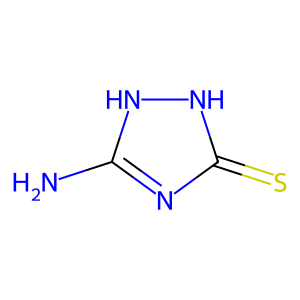

First 10 active Morgan bits: [97, 269, 378, 501, 584, 669, 697, 910, 920, 1114]
             descriptor      value
                  MolWt 116.149002
                MolLogP   0.049490
                   TPSA  70.489998
                 NumHBD   3.000000
                 NumHBA   3.000000
      NumRotatableBonds   0.000000
       NumAromaticRings   1.000000
      NumAliphaticRings   0.000000
         HeavyAtomCount   7.000000
           FractionCSP3   0.000000
NumAromaticHeterocycles   1.000000
      NumSaturatedRings   0.000000
            fr_aldehyde   0.000000
             fr_epoxide   0.000000
             fr_halogen   0.000000
                 fr_NH0   1.000000
                 fr_NH1   2.000000
                 fr_NH2   1.000000
              RingCount   1.000000
    NumRadicalElectrons   0.000000

Compound 2: NC(=O)OC[C@@H]1[C@H](NC(=O)/C(=N\OCC(=O)[O-])c2csc(N)n2)C(=O)N1S(=O)(=O)[O-]


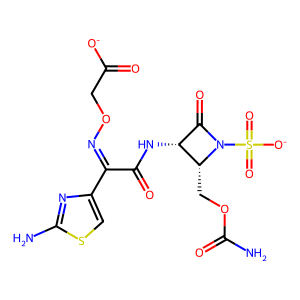

First 10 active Morgan bits: [5, 49, 80, 103, 147, 157, 231, 235, 314, 350]
             descriptor      value
                  MolWt 464.394012
                MolLogP  -4.553000
                   TPSA 259.559998
                 NumHBD   3.000000
                 NumHBA  14.000000
      NumRotatableBonds   9.000000
       NumAromaticRings   1.000000
      NumAliphaticRings   1.000000
         HeavyAtomCount  30.000000
           FractionCSP3   0.333333
NumAromaticHeterocycles   1.000000
      NumSaturatedRings   1.000000
            fr_aldehyde   0.000000
             fr_epoxide   0.000000
             fr_halogen   0.000000
                 fr_NH0   3.000000
                 fr_NH1   1.000000
                 fr_NH2   2.000000
              RingCount   2.000000
    NumRadicalElectrons   0.000000

Compound 3: COc1ccc2cc(S(=O)(=O)N[C@H](CC(=O)N[C@H](Cc3ccc(CN4[C@@H](C)CCC[C@H]4C)cc3)C(=O)N(C)C(C)C)c3ccc4c(c3)OCO4)ccc2c1


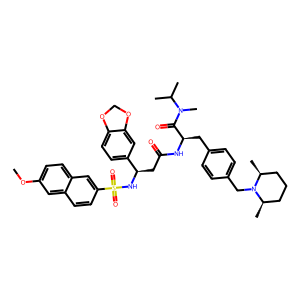

First 10 active Morgan bits: [1, 38, 41, 49, 51, 79, 80, 91, 135, 137]
             descriptor      value
                  MolWt 756.966003
                MolLogP   6.344000
                   TPSA 126.510002
                 NumHBD   2.000000
                 NumHBA   8.000000
      NumRotatableBonds  14.000000
       NumAromaticRings   4.000000
      NumAliphaticRings   2.000000
         HeavyAtomCount  54.000000
           FractionCSP3   0.428571
NumAromaticHeterocycles   0.000000
      NumSaturatedRings   1.000000
            fr_aldehyde   0.000000
             fr_epoxide   0.000000
             fr_halogen   0.000000
                 fr_NH0   2.000000
                 fr_NH1   2.000000
                 fr_NH2   0.000000
              RingCount   6.000000
    NumRadicalElectrons   0.000000


In [15]:
from IPython.display import display

sample_size = min(3, len(valid_smiles_array))
if sample_size == 0:
    print('No valid SMILES available for sanity-check visualization.')
else:
    rng = np.random.default_rng(42)
    sample_smiles = rng.choice(valid_smiles_array, size=sample_size, replace=False)
    descriptor_names = get_descriptor_names()[2048:]

    for i, smi in enumerate(sample_smiles, start=1):
        print(f'\nCompound {i}: {smi}')
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            print('Invalid SMILES encountered during sanity check.')
            continue

        img = Draw.MolToImage(mol, size=(300, 300))
        display(img)

        features = smiles_to_features(smi)
        if features is None:
            print('Feature extraction returned None unexpectedly.')
            continue

        active_bits = np.where(features[:2048] == 1)[0].tolist()[:10]
        print(f'First 10 active Morgan bits: {active_bits}')

        descriptor_values = features[2048:]
        descriptor_table = pd.DataFrame({
            'descriptor': descriptor_names,
            'value': descriptor_values
        })
        print(descriptor_table.to_string(index=False))

## Cell 8 - Feature Name Export

In [16]:
feature_names = get_descriptor_names()
feature_names_path = PROCESSED_DIR / 'feature_names.json'

with open(feature_names_path, 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, indent=2)

print(f'Saved {len(feature_names)} feature names to: {feature_names_path}')

Saved 2068 feature names to: ../processed/feature_names.json


In [19]:
# Run these checks in a cell at the end of the notebook
assert X_processed.shape[1] == 2068, "Feature vector wrong size"
assert X_processed.dtype == np.float32, "Wrong dtype"
assert not np.isnan(X_processed).any(), "NaN in features — check scaler"
assert y.shape[1] == 12, "Wrong number of assay columns"
assert len(feature_names) == 2068, "Feature names count mismatch"

# Critical: fingerprint bits should still be binary after scaling
fp_section = X_processed[:, :2048]
assert set(np.unique(fp_section)).issubset({0.0, 1.0}), \
    "Fingerprints were accidentally scaled — they must stay binary"